**Import the libraries**

In [93]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler   
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

**Load the dataset**

In [94]:
df = pd.read_csv("../../datasets/Processed_Datasets/framingham_clean.csv")

**Separate the dataset into input features X and the target variable y**

In [95]:
y = df["TenYearCHD"]
X = df.drop("TenYearCHD", axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3658, 15)
Target shape: (3658,)


**Split the data into training and testing sets**

In [96]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Training set: (2194, 15)
Validation set: (732, 15)
Testing set: (732, 15)


**Create a Logistic Regression model and train it using the training dataset**

In [97]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=5000, class_weight="balanced")
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


**predict the target values**

In [98]:
y_val_pred = log_model.predict(X_val)
y_test_pred = log_model.predict(X_test)

In [99]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation F1 Score:", f1_score(y_val, y_val_pred))

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

Validation Accuracy: 0.6762295081967213
Validation F1 Score: 0.3713527851458886
Test Accuracy: 0.6898907103825137
Test F1 Score: 0.41645244215938304


In [100]:
print("Validation Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

Validation Confusion Matrix:
[[425 208]
 [ 29  70]]

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.78       633
           1       0.25      0.71      0.37        99

    accuracy                           0.68       732
   macro avg       0.59      0.69      0.58       732
weighted avg       0.84      0.68      0.73       732


Test Confusion Matrix:
[[424 186]
 [ 41  81]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79       610
           1       0.30      0.66      0.42       122

    accuracy                           0.69       732
   macro avg       0.61      0.68      0.60       732
weighted avg       0.81      0.69      0.73       732



In [101]:
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
print("Validation Results")
print("Accuracy =", val_acc)
print("F1 Score =", val_f1)
print("Test Results")
print("Accuracy =", test_acc)
print("F1 Score =", test_f1)

Validation Results
Accuracy = 0.6762295081967213
F1 Score = 0.3713527851458886
Test Results
Accuracy = 0.6898907103825137
F1 Score = 0.41645244215938304


In [102]:
results_df = pd.DataFrame({"Model": ["Logistic Regression", "Logistic Regression"],"Dataset": ["Validation", "Test"],"Accuracy": [val_acc, test_acc],"F1 Score": [val_f1, test_f1],})
print(results_df)

                 Model     Dataset  Accuracy  F1 Score
0  Logistic Regression  Validation  0.676230  0.371353
1  Logistic Regression        Test  0.689891  0.416452


In [103]:
lr = log_model

coeff = pd.DataFrame(lr.coef_[0], X.columns, columns=['Coefficient'])
print(coeff.sort_values('Coefficient', ascending=False))

                 Coefficient
age                 0.577121
sysBP               0.272914
male                0.256369
totChol             0.131007
cigsPerDay          0.120861
currentSmoker       0.112753
glucose             0.103006
diabetes            0.085763
diaBP               0.082831
prevalentStroke     0.071091
BPMeds              0.057542
BMI                 0.034879
prevalentHyp       -0.027233
heartRate          -0.072354
education          -0.100761


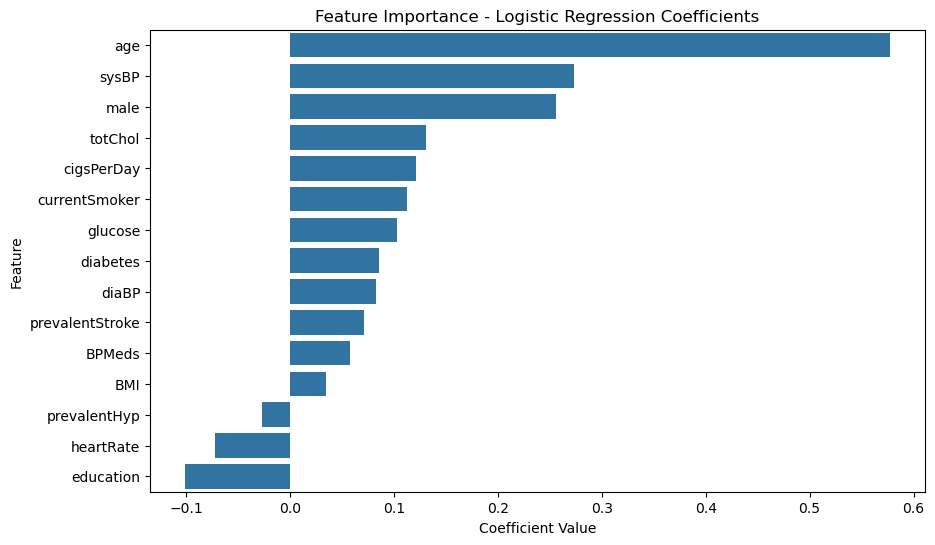

In [104]:
coeff = pd.DataFrame(log_model.coef_[0], X.columns, columns=['Coefficient'])
coeff = coeff.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=coeff["Coefficient"], y=coeff.index)
plt.title("Feature Importance - Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

**Train and evaluate a Decision Tree model on the Framingham dataset**

In [105]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
df = pd.read_csv("../../datasets/Processed_Datasets/framingham_clean.csv")
y = df["TenYearCHD"]
X = df.drop("TenYearCHD", axis=1)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_val_pred = dt_model.predict(X_val)
y_test_pred = dt_model.predict(X_test)

print("Decision Tree Results")
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation F1 Score:", f1_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

Decision Tree Results
Validation Accuracy: 0.755464480874317
Validation F1 Score: 0.21145374449339208
Test Accuracy: 0.75
Test F1 Score: 0.27091633466135456


**Train and evaluate a Random Forest model on the Framingham dataset**

In [106]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
df = pd.read_csv("../../datasets/Processed_Datasets/framingham_clean.csv")
y = df["TenYearCHD"]
X = df.drop("TenYearCHD", axis=1)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation F1 Score:", f1_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

Random Forest Results
Validation Accuracy: 0.8510928961748634
Validation F1 Score: 0.05217391304347826
Test Accuracy: 0.8333333333333334
Test F1 Score: 0.08955223880597014
